In [1]:
import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
from matplotlib.pyplot import rc_context



In [2]:

# --- INIT ---

# get the user folder
user_folder = "/".join(os.getcwd().split("/")[:3])

# which data to use
head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % user_folder
hvg_to_use = 'transformed_X_outlier_variance'
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
reg_head_folder = '%s/bayesian_harmonic_reg' % clustering_folder
de_folder_out = '%s/de' % clustering_folder
marker_gene_dict_path = '%s/marker_gene_dict.txt' % (de_folder_out)



In [3]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [12]:
# --- LOAD HVG AND LIMIT ADATA TO THEM ---

torch_model_path_out = '%s/scvi_model_torch.pt' % scvi_res_folder
hv_path = '%s/var_names.csv' % torch_model_path_out
hvg_df = pd.read_table(hv_path,sep=',',header=None)
hvg = list(hvg_df.iloc[:,0])
adata = adata[:,hvg]

adata


View of AnnData object with n_obs × n_vars = 145271 × 1150
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])













/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


In [5]:
# --- GET THE UNIQUE CLUSTERS ---

clusters = sorted(list(adata.obs['cluster'].unique()))



In [14]:
# --- RECONSTRUCT THE GENE SAMPLES MAT ---

gene_samples_mat = None # ultimately will be: [num_cell_types x num_samples x num_genes]
for cluster_index,cluster in enumerate(clusters):
    fileout = '%s/cluster_%s_gene_samples_mat.npy' % (de_folder_out,cluster_index)
    cluster_gene_samples = np.loadtxt(fileout) # gene_samples_mat[cluster_index,:,:])
    if gene_samples_mat is None:
        gene_samples_mat = np.zeros((len(clusters), cluster_gene_samples.shape[0], cluster_gene_samples.shape[1]))
    gene_samples_mat[cluster_index,:,:] = cluster_gene_samples
    
    
    

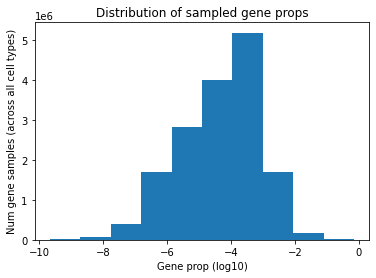

In [24]:
# --- MAKE SURE THE GENE PROPS LOOK REASONABLE ---

plt.clf()
plt.hist(np.log10(gene_samples_mat.flatten()))
plt.title("Distribution of sampled gene props")
plt.xlabel("Gene prop (log10)")
plt.ylabel("Num gene samples (across all cell types)")
plt.show()


In [30]:
# --- RESHAPE GENE SAMPLES MAT ---

# reshape
gene_samples_mat_reshaped = gene_samples_mat.reshape(gene_samples_mat.shape[0] * gene_samples_mat.shape[1],gene_samples_mat.shape[2])

# get the corresponding labels of the cell types
cell_type_samples_mat = np.zeros((gene_samples_mat.shape[0],gene_samples_mat.shape[1]))
for cluster_index,cluster in enumerate(clusters):
    cell_type_samples_mat[cluster_index,:] = cluster
cell_type_samples_mat_reshaped = cell_type_samples_mat.reshape(gene_samples_mat.shape[0] * gene_samples_mat.shape[1])




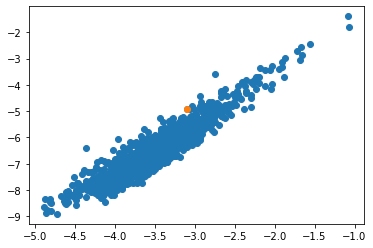

In [44]:
# --- GET THE MEAN VARIANCE RELATIONSHIP FOR EACH GENE ---

gene_mean = np.mean(gene_samples_mat_reshaped,axis=0)
gene_var = np.var(gene_samples_mat_reshaped,axis=0)

plt.clf()
plt.scatter(np.log10(gene_mean),np.log10(gene_var))
plt.scatter(np.log10(gene_mean)[69],np.log10(gene_var)[69])



In [43]:

np.where(adata.var_names == 'Rgs5')


(array([69]),)

In [38]:
np.log10(gene_mean[952])

-2.601406180351445

In [39]:
np.log10(gene_var[952])

-4.4219228923548535